In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
students = pd.read_csv("student_performance.csv")

In [64]:
students.head()

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade
0,1,John,Male,85,15,78,1,High,80
1,2,Sarah,Female,90,20,85,2,Medium,87
2,3,Alex,Male,78,10,65,0,Low,68
3,4,Michael,Male,92,25,90,3,High,92
4,5,Emma,Female,88,18,82,2,Medium,85


In [65]:
students.tail()

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade
5,6,Olivia,Female,95,30,88,1,High,90
6,7,Daniel,Male,70,8,60,0,Low,62
7,8,Sophia,Female,85,17,77,1,Medium,78
8,9,James,Male,82,12,70,2,Low,72
9,10,Isabella,Female,91,22,86,3,High,88


In [66]:
students.shape

(10, 9)

In [67]:
students.columns

Index(['StudentID', 'Name', 'Gender', 'AttendanceRate', 'StudyHoursPerWeek',
       'PreviousGrade', 'ExtracurricularActivities', 'ParentalSupport',
       'FinalGrade'],
      dtype='object')

In [68]:
students.dtypes

,0
StudentID,int64
Name,object
Gender,object
AttendanceRate,int64
StudyHoursPerWeek,int64
PreviousGrade,int64
ExtracurricularActivities,int64
ParentalSupport,object
FinalGrade,int64


In [69]:
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   StudentID                  10 non-null     int64 
 1   Name                       10 non-null     object
 2   Gender                     10 non-null     object
 3   AttendanceRate             10 non-null     int64 
 4   StudyHoursPerWeek          10 non-null     int64 
 5   PreviousGrade              10 non-null     int64 
 6   ExtracurricularActivities  10 non-null     int64 
 7   ParentalSupport            10 non-null     object
 8   FinalGrade                 10 non-null     int64 
dtypes: int64(6), object(3)
memory usage: 852.0+ bytes


In [70]:
students.describe()

,StudentID,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,FinalGrade
count,10.00000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,5.50000,85.600000,17.700000,78.100000,1.500000,80.200000
std,3.02765,7.441625,6.848357,10.170218,1.080123,10.097304
min,1.00000,70.000000,8.000000,60.000000,0.000000,62.000000
25%,3.25000,82.750000,12.750000,71.750000,1.000000,73.500000
50%,5.50000,86.500000,17.500000,80.000000,1.500000,82.500000
75%,7.75000,90.750000,21.500000,85.750000,2.000000,87.750000
max,10.00000,95.000000,30.000000,90.000000,3.000000,92.000000


In [71]:
df["FinalGrade"].mean()

np.float64(80.2)

In [72]:
df["FinalGrade"].median()

82.5

In [73]:
df.isnull().sum()

,0
StudentID,0
Name,0
Gender,0
AttendanceRate,0
StudyHoursPerWeek,0
PreviousGrade,0
ExtracurricularActivities,0
ParentalSupport,0
FinalGrade,0


In [74]:
df["StudyHoursPerWeek"] = df["StudyHoursPerWeek"].fillna(
    df["StudyHoursPerWeek"].median()
)

In [75]:
df["StudyHoursPerWeek"]

,StudyHoursPerWeek
0,15
1,20
2,10
3,25
4,18
5,30
6,8
7,17
8,12
9,22


In [76]:
df["StudyHoursPerWeek"].median()

17.5

In [77]:
df.duplicated().sum()

np.int64(0)

In [78]:
df["Gender"].unique()

array(['Male', 'Female'], dtype=object)

In [79]:
df["Gender"].value_counts()

,count
Gender,
Male,5
Female,5


In [80]:
high_scores = df[
    (df["FinalGrade"] >= 90) & (df["StudyHoursPerWeek"] >= 4) & (df["AttendanceRate"] >= 80)
]

In [81]:
df["FinalGrade"]

,FinalGrade
0,80
1,87
2,68
3,92
4,85
5,90
6,62
7,78
8,72
9,88


In [82]:
df.sort_values(
    by="FinalGrade",
    ascending=False
)

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade
3,4,Michael,Male,92,25,90,3,High,92
5,6,Olivia,Female,95,30,88,1,High,90
9,10,Isabella,Female,91,22,86,3,High,88
1,2,Sarah,Female,90,20,85,2,Medium,87
4,5,Emma,Female,88,18,82,2,Medium,85
0,1,John,Male,85,15,78,1,High,80
7,8,Sophia,Female,85,17,77,1,Medium,78
8,9,James,Male,82,12,70,2,Low,72
2,3,Alex,Male,78,10,65,0,Low,68
6,7,Daniel,Male,70,8,60,0,Low,62


In [83]:
df.groupby("Gender")["FinalGrade"].mean()

,FinalGrade
Gender,
Female,85.6
Male,74.8


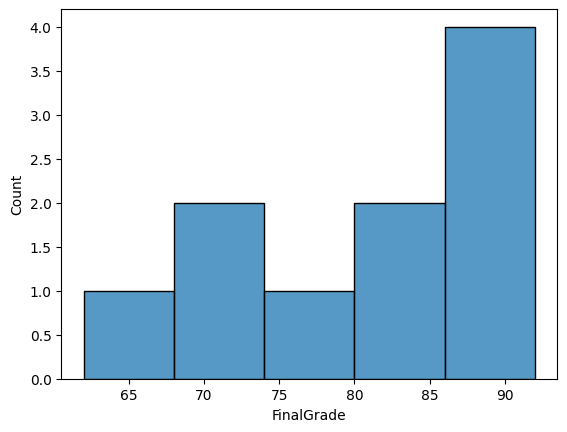

In [85]:
sns.histplot(
    data=df,
    x="FinalGrade"
)

plt.show()

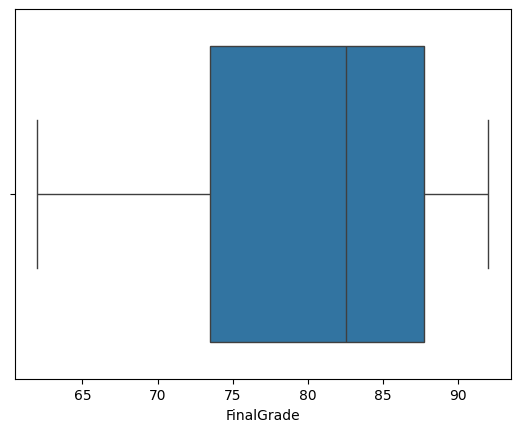

In [86]:
sns.boxplot(
    data=df,
    x="FinalGrade"
)

plt.show()


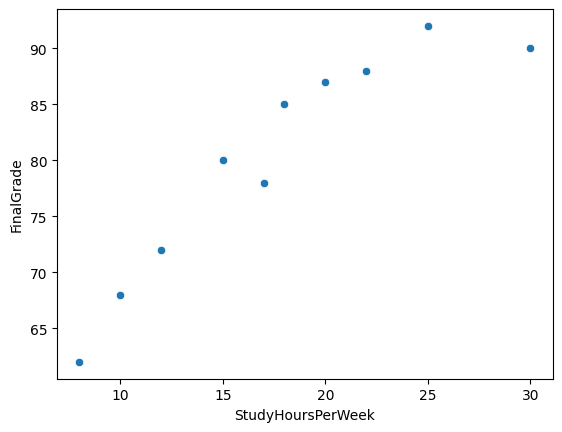

In [87]:
sns.scatterplot(
    data=df,
    x="StudyHoursPerWeek",
    y="FinalGrade"
)

plt.show()
#

In [88]:
df["StudyHoursPerWeek"].corr(
    df["FinalGrade"]
)

#shows proper linear correlation between StudyHoursPerWeek and Final Grade

np.float64(0.9264889832015147)

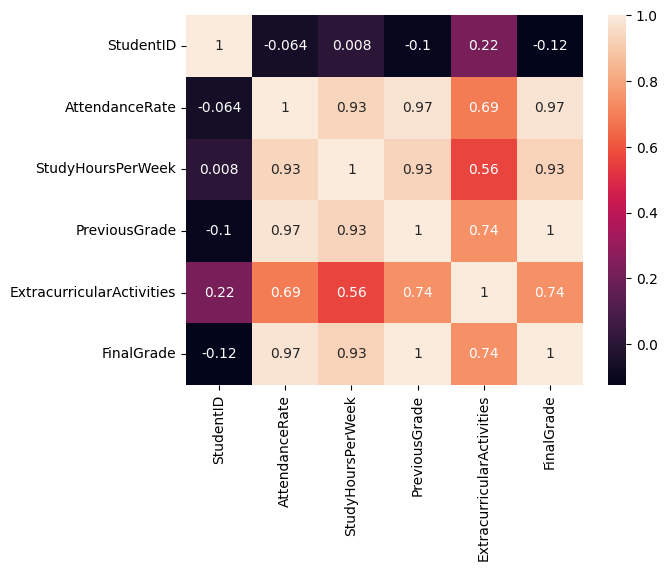

In [89]:
corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True
)

plt.show()

In [90]:
def clean_data(df):

    df = df.copy()

    df = df.drop_duplicates()

    df["StudyHoursPerWeek"] = df["StudyHoursPerWeek"].fillna(
        df["StudyHoursPerWeek"].median()
    )

    df["AttendanceRate"] = df["AttendanceRate"].fillna(
        df["AttendanceRate"].median()
    )

    return df

In [91]:
df = clean_data(df)

In [93]:
def plot_score_distrubtion():

  sns.histplot(
      data=df,
      x="FinalGrade"
  )
  plt.title("Score Distribution")
  plt.xlabel("Final Grade")
  plt.ylabel("Number of Sutdents")

  plt.show()


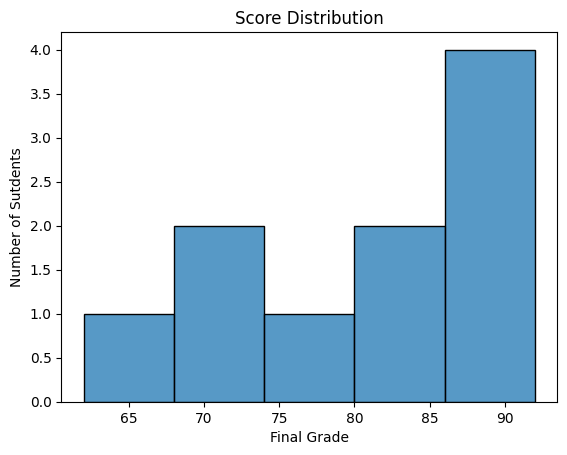

In [94]:
plot_score_distrubtion()

In [97]:
def dataset_summary(df):

  print("Rows:", df.shape(0))
  print("Columns:", df.shape(1))
  print("Missing Values")
  print(df.isnull().sum())

  print("Duplicated Values")
  print(df.duplicated().sum())

  print("\nDatatypes: ")
  print(df.dtypes)

In [101]:
def dataset_summary(df):

  print("Rows:", df.shape[0])
  print("Columns:", df.shape[1])
  print("Missing Values")
  print(df.isnull().sum())

  print("Duplicated Values")
  print(df.duplicated().sum())

  print("\nDatatypes: ")
  print(df.dtypes)

dataset_summary(df)

Rows: 10
Columns: 9
Missing Values
StudentID                    0
Name                         0
Gender                       0
AttendanceRate               0
StudyHoursPerWeek            0
PreviousGrade                0
ExtracurricularActivities    0
ParentalSupport              0
FinalGrade                   0
dtype: int64
Duplicated Values
0

Datatypes: 
StudentID                     int64
Name                         object
Gender                       object
AttendanceRate                int64
StudyHoursPerWeek             int64
PreviousGrade                 int64
ExtracurricularActivities     int64
ParentalSupport              object
FinalGrade                    int64
dtype: object
